In [2]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sparse import COO
%load_ext memory_profiler
plt.rc('figure', figsize=(4.0, 3.0))
sns.set_theme(style='white')
imgpath=Path('../../docs/user-guide/img/')

In [3]:
n_cols=1000
n_rows=5000
B = nx.bipartite.random_graph(n_cols,n_rows, .005, seed=2)
n = list(B.nodes)[n_cols:]

X = COO.from_scipy_sparse(nx.bipartite.biadjacency_matrix(B, n)).astype(bool)
X

Format,coo
Data Type,bool
Shape,"(5000, 1000)"
nnz,24976
Density,0.0049952
Read-only,True
Size,414.6K
Storage ratio,0.08


## Sparse Squareform

We can use the identities in [Angeletti et al](https://hal.science/hal-02047514) to derive _sparse_-friendly versions of the [`scipy.spatial.distance.squareform`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.squareform.html) operations and laplacian/covariance/co-occurrence normalization (symmetric/correlation/cosine-similarity). 

In [4]:
from affinis.utils import sq_e_ij, sq_ij_e, _sq, csr_rows_idx
from sparse import diagonal, triu, stack

%psource sq_ij_e

def sq_ij_e(n: int, ij: tuple[Idx, Idx]) -> Idx:
    """Closed-form expression to map edge-to-node-pair indices.

    Get an edge index from a row-column index pai  upper-triangle of a
    symmetric matrix.

    Parameters:
        n: dimension of square/symmetric matrix
        ij: pair of row(s),column(s) indices in corresponding matrix.

    Returns:
        index of edge(s) from vector-representation
    """
    i, j = ij
    e = (n * (n - 1) / 2) - (n - i) * ((n - i) - 1) / 2 + j - i - 1
    return e.astype(int)
    # return _map_edge_to_nodes(n).inverse[ij]


In [5]:
%psource sq_e_ij

def sq_e_ij(n: int, e: Idx) -> tuple[Idx, Idx]:
    """Closed-form expression to map edge-to-node-pair indices.

    Get a row-column location in the upper-triangle of a symmetric
    matrix, given the linear index of it's unrolled vector representation.

    Parameters:
        n: dimension of square/symmetric matrix
        e: index of edge(s) from vector-representation

    Returns:
        pair of row(s),column(s) indices in corresponding matrix.
    """
    i = n - 2 - np.floor(np.sqrt(-8 * e + 4 * n * (n - 1) - 7) / 2.0 - 0.5)
    j = e + i + 1 - n * (n - 1) / 2 + (n - i) * ((n - i) - 1) / 2
    return i.astype(int), j.astype(int)
    # return _map_edge_to_nodes(n)[e]


In [6]:
def sq_flat(A):
    n = min(A.shape[-1],A.shape[-2])
    # coord_mask = a.coords[0]<a.coords[1]
    # idxs=a.coords[:,coord_mask]
    # coords = sq_ij_e(n, idxs)
    # return COO(shape=[int(n*n/2-n/2),], coords=coords, data=a.data[coord_mask])
    a=triu(A, k=1)  # wow this works with ndim>2 as well! 
    coords = sq_ij_e(n, a.coords[-2:,:])  # which means I can too!
    shape = int(n*n/2-n/2)
   
    if a.ndim>2:  # maybe there's a slicing/indexing way to make implicit
        coords =  np.vstack([a.coords[0], coords])
        shape = (a.shape[0],shape)
    return COO(shape=shape, coords=coords, data=a.data)

def sq_sq(e):
    ## NOT CURRENTLY BATCH-DIM COMPATIBLE
    n = int(np.ceil(np.sqrt(e.shape[0] * 2)))
    # Check that e is of valid dimensions.
    if n * (n - 1) != e.shape[0] * 2:  # identical check from scipy
        raise ValueError(
            'Incompatible vector size. It must be a triangular number.'
        )
    tri_coords=sq_e_ij(n, e.coords[0])
    tri=COO(coords=tri_coords, shape=(n,n), data=e.data)
    return tri+tri.T

def norm_diag_sprs(Sq):
    d=diagonal(Sq)
    d_a=d[Sq.coords[0]]
    d_b=d[Sq.coords[1]]
    # Do I need to worry about sqrt div? simSIMD uses Newton-Raphson...
    return COO(data=Sq.data/np.sqrt(d_a*d_b).todense(), coords=Sq.coords) 
    
def sparse_cos(X):
    D = X.T@X
    return norm_diag_sprs(D)

### Testing fold/unfold Space Needs

In [28]:
from sparse import random
old_perfs = []
new_perfs = []
szs = [10,100,1000,5000, 10000, 20000]

for sz in szs:
    A = random((sz,sz))
    new_perf = %timeit -o sq_sq(sq_flat(A))
    new_perfs += [new_perf]
    old_perf = %timeit -o _sq(_sq(A.todense()))
    old_perfs += [old_perf]



355 μs ± 16.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
5.13 μs ± 41.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
379 μs ± 10.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
10.7 μs ± 125 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
1.5 ms ± 9.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
926 μs ± 234 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
34.1 ms ± 4.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
97.5 ms ± 3.98 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
160 ms ± 737 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
449 ms ± 55.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
654 ms ± 10.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
6.28 s ± 913 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


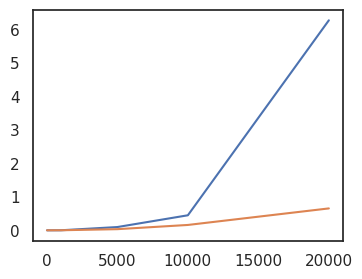

In [33]:
plt.plot(szs,[i.average for i in old_perfs])
plt.plot(szs,[i.average for i in new_perfs])
# plt.yscale('log')


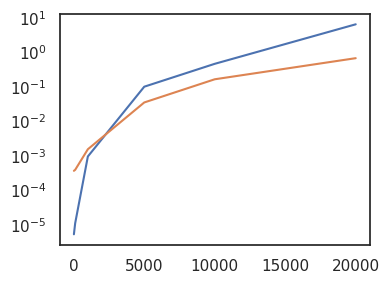

In [34]:
plt.plot(szs,[i.average for i in old_perfs])
plt.plot(szs,[i.average for i in new_perfs])
plt.yscale('log')

In [82]:
%memit sq_sq(sq_flat(A))
%memit _sq(_sq(A.todense()))

peak memory: 900.53 MiB, increment: 0.00 MiB
peak memory: 2044.91 MiB, increment: 1144.38 MiB


### Improving Cosine Sim Sparsity

In [98]:
from scipy.sparse import csc_array
from affinis.associations import ochiai
bigX = random((10000,5000), density=0.001)

%memit sparse_cos(bigX)
%memit ochiai(csc_array(bigX.to_scipy_sparse()))


peak memory: 1165.46 MiB, increment: 0.00 MiB
peak memory: 1736.98 MiB, increment: 571.52 MiB


### Improving Edge ID extraction

Now we can make an explicit representation of the original data, as cliques. 
The _Desire-path Density_ model says that we should select a subgraph of each of these cliques, to aggregate for an overall (conditional) edge probability. 

In [47]:
Xclique = sq_flat(einsum('bi,bo->bio', X, X))
Xclique

Format,coo
Data Type,int64
Shape,"(5000, 499500)"
nnz,62260
Density,2.492892892892893e-05
Read-only,True
Size,1.4M
Storage ratio,0.00


/home/rtbs/code/thesis/affinis/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/rtbs/code/thesis/affinis/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

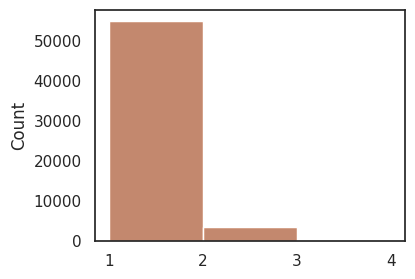

In [48]:
sns.histplot((Xclique.sum(axis=0)).data)
sns.histplot(sq_flat(X.T@X).data)
# sq_flat(X.T@X).data

Let's get the LIL representation to make future application of Forest Pursuit easier. 
Now that we have a way to unroll batch tensors, we can compare the clique edge index retrieval via both that and the previous `itertools.combinations` way

In [58]:
from itertools import combinations, islice
from sparse import einsum
from affinis.utils import complete_edgelist_on_nodes
# %timeit 
def edge_candidates_einsum(X):
    # yield from (sq_flat(i).coords[0] for i in triu(einsum('bi,bo->bio', DTM, DTM), k=1))
    # yield from triu(einsum('bi,bo->bio', DTM, DTM), k=1) 
    # yield from (sq_ij_e(DTM.shape[1],i.coords) for i in einsum('bi,bo->bio', DTM, DTM))
    # yield from (i.coords for i in triu(einsum('bi,bo->bio', DTM, DTM), k=1))
    yield from csr_rows_idx(sq_flat(einsum('bi,bo->bio', X, X)).tocsr())

def edge_candidates_affinis(X):
    n = X.shape[1]
    yield from (complete_edgelist_on_nodes(n,i) for i in csr_rows_idx(X.tocsr()))

    
def edge_candidates_itertl(X):
    yield from (sq_ij_e(X.shape[1],np.array(list(combinations(i.tolist(),2))).T) 
     if len(i)>1
     else np.array([])
     for i in csr_rows_idx(X.tocsr())
    )

In [61]:
list(islice(edge_candidates_affinis(X),3))

[array([321063, 321507, 321530, 321534, 359228, 359251, 359255, 495781,
        495785, 497487]),
 array([186364, 186512, 186514, 186855, 186893, 186948, 261252, 261254,
        261595, 261633, 261688, 352348, 352689, 352727, 352782, 353770,
        353808, 353863, 479637, 479692, 486513]),
 array([  6056,   6125,   6216,   6654,   6924,   6962,  80498,  80589,
         81027,  81297,  81335, 141309, 141747, 142017, 142055, 214547,
        214817, 214855, 449366, 449404, 498409])]

In [62]:
list(islice(edge_candidates_einsum(X), 3))

[array([321063, 321507, 321530, 321534, 359228, 359251, 359255, 495781,
        495785, 497487], dtype=int32),
 array([186364, 186512, 186514, 186855, 186893, 186948, 261252, 261254,
        261595, 261633, 261688, 352348, 352689, 352727, 352782, 353770,
        353808, 353863, 479637, 479692, 486513], dtype=int32),
 array([  6056,   6125,   6216,   6654,   6924,   6962,  80498,  80589,
         81027,  81297,  81335, 141309, 141747, 142017, 142055, 214547,
        214817, 214855, 449366, 449404, 498409], dtype=int32)]

In [63]:
list(islice(edge_candidates_itertl(X), 3))

[array([321063, 321507, 321530, 321534, 359228, 359251, 359255, 495781,
        495785, 497487]),
 array([186364, 186512, 186514, 186855, 186893, 186948, 261252, 261254,
        261595, 261633, 261688, 352348, 352689, 352727, 352782, 353770,
        353808, 353863, 479637, 479692, 486513]),
 array([  6056,   6125,   6216,   6654,   6924,   6962,  80498,  80589,
         81027,  81297,  81335, 141309, 141747, 142017, 142055, 214547,
        214817, 214855, 449366, 449404, 498409])]

### Testing Edge ID extraction

In [64]:
from collections import deque

%timeit deque(edge_candidates_affinis(X), maxlen=0)
%timeit deque(edge_candidates_einsum(X), maxlen=0)
%timeit deque(edge_candidates_itertl(X), maxlen=0)

219 ms ± 5.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
23 ms ± 799 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
97.4 ms ± 1.34 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Einsum in `sparse` is a huge savings, now that the `squareform` operator works natively!